In [10]:
import pandas as pd
import numpy as np
from snowflake.snowpark import Session
import matplotlib.pyplot as plt


In [2]:
connection_parameters = {
    "account": "IJYGGJU-WI05238",
    "user": "Shank227",
    "password": "ShashankB2207$",
    "warehouse": "COMPUTE_WH",
    "database": "BANK_SEGMENTATION_DB",
    "schema": "PUBLIC",
    "role": "ACCOUNTADMIN"
}

In [4]:
df = pd.read_csv("encoded_dataset.csv")

In [8]:
session = Session.builder.configs(connection_parameters).create()
cluster_df = session.table("CUSTOMER_CLUSTERS").to_pandas()

In [9]:
df["Cluster"] = cluster_df["Cluster"]

In [ ]:
cluster_labels = {
    0: "Low Engagement",
    1: "Previously Engaged",
    2: "Developing"
}

df["Segment"] = df["Cluster"].map(cluster_labels)

In [17]:
cluster_counts = df["Segment"].value_counts()

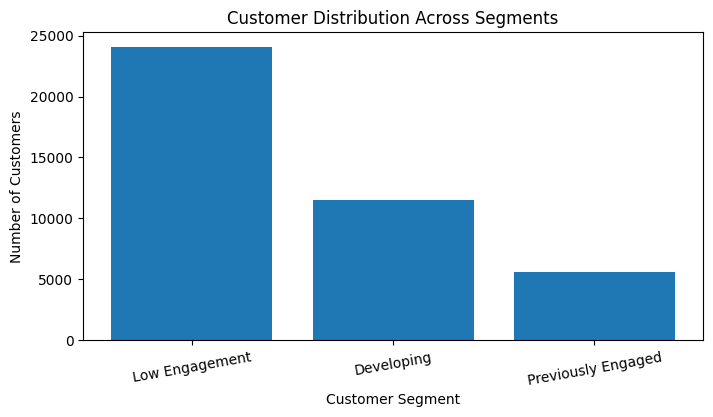

In [ ]:
# Cluster Distribution (How many customers belong to each segment)

cluster_counts = df["Segment"].value_counts()

plt.figure(figsize=(8,4))
plt.bar(cluster_counts.index, cluster_counts.values)

plt.title("Customer Distribution Across Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=10)   # optional, rotates labels slightly

plt.show()

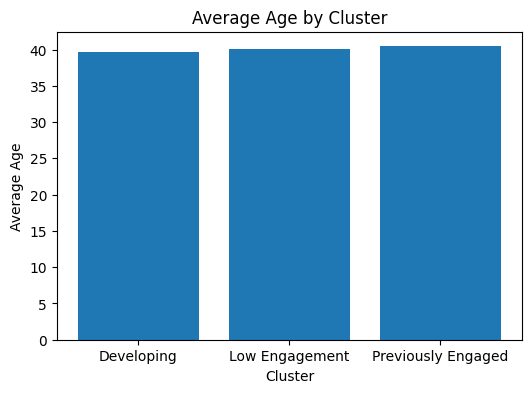

In [25]:
# Average age of costumers per cluster
age_profile = df.groupby("Segment")["age"].mean()

plt.figure(figsize=(6,4))
plt.bar(age_profile.index.astype(str), age_profile.values)

plt.title("Average Age by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Age")

plt.show()

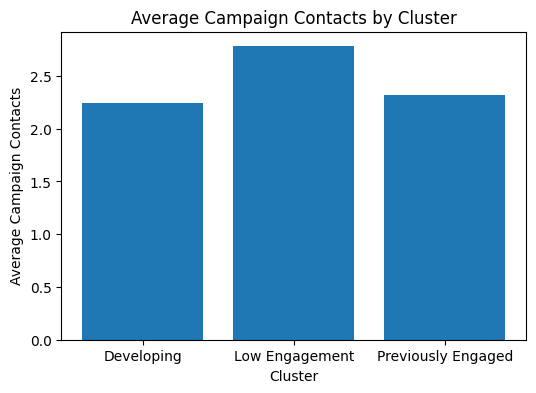

In [26]:
# Capaign Frequency (which costumers required the most marekting efforts)
campaign_profile = df.groupby("Segment")["campaign"].mean()

plt.figure(figsize=(6,4))
plt.bar(campaign_profile.index.astype(str), campaign_profile.values)

plt.title("Average Campaign Contacts by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Campaign Contacts")

plt.show()

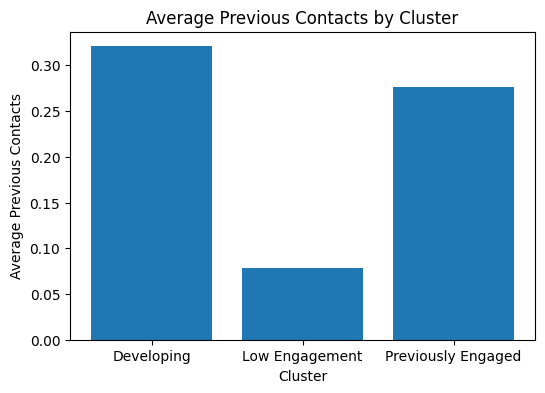

In [27]:
# Previous Contact (Which costumers already had relationship with the bank)
previous_profile = df.groupby("Segment")["previous"].mean()

plt.figure(figsize=(6,4))
plt.bar(previous_profile.index.astype(str), previous_profile.values)

plt.title("Average Previous Contacts by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Previous Contacts")

plt.show()